In [ ]:
import os
import gc
import cv2
import numpy as np
import pandas as pd
from glob import glob
import tensorflow as tf
from tensorflow import keras
from sklearn.utils import shuffle
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, regularizers, backend as K
from tensorflow.keras.preprocessing import image_dataset_from_directory, LabelEncoder
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2
import kagglehub
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score, classification_report, confusion_matrix
K.clear_session()
gc.collect()

2026-06-09 11:09:48.336184: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781003388.527799      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781003388.581767      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781003389.001376      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781003389.001419      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781003389.001424      23 computation_placer.cc:177] computation placer alr

0

In [2]:
# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# GPU memory safety (Jupyter)
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

K.clear_session()
gc.collect()

0

# Load Image Data

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 64

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

## Binary Class (Kermany)

In [ ]:
data_dir = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

cat = ["Normal", "Pneumonia"]

le = LabelEncoder()

def make_df(path):

    data = []

    for split in ["train", "val", "test"]:

        split_path = os.path.join(path, split)

        for label in os.listdir(split_path):

            label_path = os.path.join(split_path, label)

            if not os.path.isdir(label_path):
                continue

            for img_name in os.listdir(label_path):

                img_path = os.path.join(label_path, img_name)

                data.append({
                    "split": split,
                    "label": label,
                    "image_path": img_path
                })

    return pd.DataFrame(data)

main_df = make_df(data_dir)

X_train, X_temp = train_test_split(
    main_df,
    test_size=0.2,
    stratify=main_df["label"],
    random_state=SEED
)

X_val, X_test = train_test_split(
    X_temp,
    test_size=0.5,
    stratify=X_temp["label"],
    random_state=SEED
)

le.fit(main_df["label"])

y_train = le.transform(X_train["label"])
y_val   = le.transform(X_val["label"])
y_test  = le.transform(X_test["label"])

num_classes = len(le.classes_)

augment = tf.keras.Sequential([
    # tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.02),
    tf.keras.layers.RandomZoom(0.02),
    tf.keras.layers.RandomTranslation(0.02, 0.02),
    tf.keras.layers.RandomContrast(0.1),
])

def augment_fn(x, y):
    x = augment(x, training=True)
    return x, y

def load_image(path, label):

    img = tf.io.read_file(path)

    img = tf.image.decode_jpeg(img, channels=3)

    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    label = tf.cast(label, tf.int32)

    return img, label

def make_dataset(img_paths, labels, training=False):

    ds = tf.data.Dataset.from_tensor_slices((img_paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.cache()
        ds = ds.shuffle(buffer_size=len(img_paths), seed=SEED)
        # ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return ds

train_ds = make_dataset(
    X_train["image_path"],
    y_train,
    training=True
)

val_ds = make_dataset(
    X_val["image_path"],
    y_val
)

test_ds = make_dataset(
    X_test["image_path"],
    y_test
)

I0000 00:00:1781003414.263665      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## 4 Class Dataset (Rahman)

In [ ]:
# data_dir = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"
# MODEL_DIR = "./saved_models"

# os.makedirs(MODEL_DIR, exist_ok=True)
# os.listdir(data_dir)
# cat = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
# num_classes = 4

# X = []
# M = []
# y = []

# for category in cat:
#     label = cat.index(category)

#     img_dir = os.path.join(data_dir, category, 'images')
#     mask_dir = os.path.join(data_dir, category, 'masks')

#     for filename in os.listdir(img_dir):

#         img_path = os.path.join(img_dir, filename)
#         mask_path = os.path.join(mask_dir, filename)

#         X.append(img_path)
#         M.append(mask_path)
#         y.append(label)


# X_train, X_temp, M_train, M_temp, y_train, y_temp = train_test_split(
#     X, M, y,
#     test_size=0.2,
#     stratify=y,
#     random_state=SEED
# )

# X_val, X_test, M_val, M_test, y_val, y_test = train_test_split(
#     X_temp, M_temp, y_temp,
#     test_size=0.5,
#     stratify=y_temp,
#     random_state=SEED
# )

In [ ]:
# ===============LOAD IMAGES WITHOUT MASK======================

# def load_image(path, label):
#     img = tf.io.read_file(path)
#     img = tf.image.decode_jpeg(img, channels=3)
#     img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
#     img = tf.cast(img, tf.float32)
#     return img, label

# def make_dataset(paths, labels, training=False):
#     ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    
#     ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    
#     if training:
#         ds = ds.cache()
#         ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    
#     ds = ds.batch(BATCH_SIZE)
#     ds = ds.prefetch(tf.data.AUTOTUNE)
    
#     return ds
# train_ds = make_dataset(X_train, y_train, training=True)
# val_ds   = make_dataset(X_val, y_val)
# test_ds  = make_dataset(X_test, y_test)

# ===============LOAD IMAGES WITH MASK======================

# USE_MASK = True

# def load_image(path, label, mask_path=None):
#     # load image
#     img = tf.io.read_file(path)
#     img = tf.image.decode_jpeg(img, channels=3)
#     img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
#     img = tf.cast(img, tf.float32)

#     # use mask if enabled
#     if USE_MASK and mask_path is not None:
#         mask = tf.io.read_file(mask_path)
#         mask = tf.image.decode_jpeg(mask, channels=1)
#         mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE))

#         # normalize mask to [0,1]
#         mask = tf.cast(mask, tf.float32) / 255.0

#         # attention weighting
#         img = img * (1.0 + mask)

#     return img, label


# def make_dataset(paths, labels, mask_paths=None, training=False):

#     # dataset format depends on mask usage
#     if USE_MASK and mask_paths is not None:
#         ds = tf.data.Dataset.from_tensor_slices((paths, labels, mask_paths))

#         ds = ds.map(
#             lambda p, l, m: load_image(p, l, m),
#             num_parallel_calls=tf.data.AUTOTUNE
#         )

#     else:
#         ds = tf.data.Dataset.from_tensor_slices((paths, labels))

#         ds = ds.map(
#             lambda p, l: load_image(p, l),
#             num_parallel_calls=tf.data.AUTOTUNE
#         )

#     if training:
#         ds = ds.cache()
#         ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

#     ds = ds.batch(BATCH_SIZE)
#     ds = ds.prefetch(tf.data.AUTOTUNE)

#     return ds

# train_ds = make_dataset(X_train, y_train, M_train, training=True)
# val_ds   = make_dataset(X_val, y_val, M_val)
# test_ds  = make_dataset(X_test, y_test, M_test)

# Build Model

In [ ]:
def focal_loss(gamma=2.0, alpha=None):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true = tf.one_hot(y_true, depth=y_pred.shape[-1])

        pt = tf.reduce_sum(y_true * y_pred, axis=-1)
        return -alpha * (1 - pt) ** gamma * tf.math.log(pt + 1e-8)
    return loss

In [ ]:
def build_model():
    cnn_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    
    x = layers.Rescaling(1.0 / 255)(cnn_input)
    
    conv_outputs = []
    
    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters=filters, kernel_size=3, padding="same",
                          kernel_regularizer=regularizers.l2(0.01))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
    
        conv_outputs.append(x)
        
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(0.2)(x)
    
    target_size = conv_outputs[-1].shape[1:3]
    
    aligned = [
         layers.Resizing(target_size[0], target_size[1])(
            layers.Conv2D(64, 1, padding="same")(feat)
        )
        for feat in conv_outputs
    ]
    
    concat = layers.Concatenate()(aligned)
    concat = layers.Add()([concat,conv_outputs[-1]])
    
    last_feat = conv_outputs[-1]
    concat_resized = layers.Resizing(target_size[0], target_size[1])(concat)
    
    x = layers.Concatenate()([concat_resized, last_feat])
    
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    
    
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.02))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.01))(x)
    output = layers.Dense(num_classes, activation="softmax")(x)
    
    model = models.Model(inputs=cnn_input, outputs=output)

    return model

# model = models.Model(inputs=cnn_input, outputs=output)

In [14]:
import time
Callback = tf.keras.callbacks.Callback

class TimeHistory(Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.time() - self.start_time)



========== SEED 42 ==========
Epoch 1/100


I0000 00:00:1781003449.951969      68 service.cc:152] XLA service 0x7b9624002340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781003449.952009      68 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781003450.881822      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/74 ━━━━━━━━━━━━━━━━━━━━ 59:21 49s/step - accuracy: 0.2188 - loss: 12.8477

I0000 00:00:1781003465.630913      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


74/74 ━━━━━━━━━━━━━━━━━━━━ 75s 359ms/step - accuracy: 0.7911 - loss: 8.1292 - val_accuracy: 0.7287 - val_loss: 2.8936 - learning_rate: 0.0010
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 164ms/step - accuracy: 0.8865 - loss: 1.2737 - val_accuracy: 0.7287 - val_loss: 1.7053 - learning_rate: 0.0010
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 164ms/step - accuracy: 0.8763 - loss: 0.6105 - val_accuracy: 0.7287 - val_loss: 3.5255 - learning_rate: 0.0010
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 165ms/step - accuracy: 0.9034 - loss: 0.4339 - val_accuracy: 0.7287 - val_loss: 1.8891 - learning_rate: 0.0010
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 165ms/step - accuracy: 0.8996 - loss: 0.3975 - val_accuracy: 0.7287 - val_loss: 4.5133 - learning_rate: 0.0010
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 164ms/step - accuracy: 0.9065 - loss: 0.3854 - val_accuracy: 0.7287 - val_loss: 1.0695 - learning_rate: 0.0010
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 12s 165ms/step - accuracy: 0.9189 - loss: 0.3273 

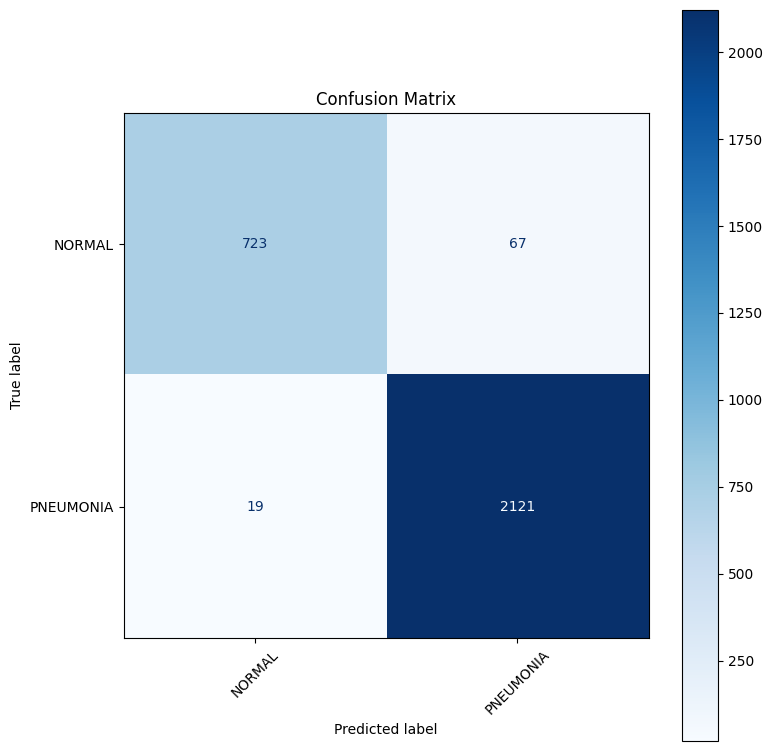


=== POOLED CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Normal     0.9744    0.9152    0.9439       790
   Pneumonia     0.9694    0.9911    0.9801      2140

    accuracy                         0.9706      2930
   macro avg     0.9719    0.9532    0.9620      2930
weighted avg     0.9707    0.9706    0.9704      2930



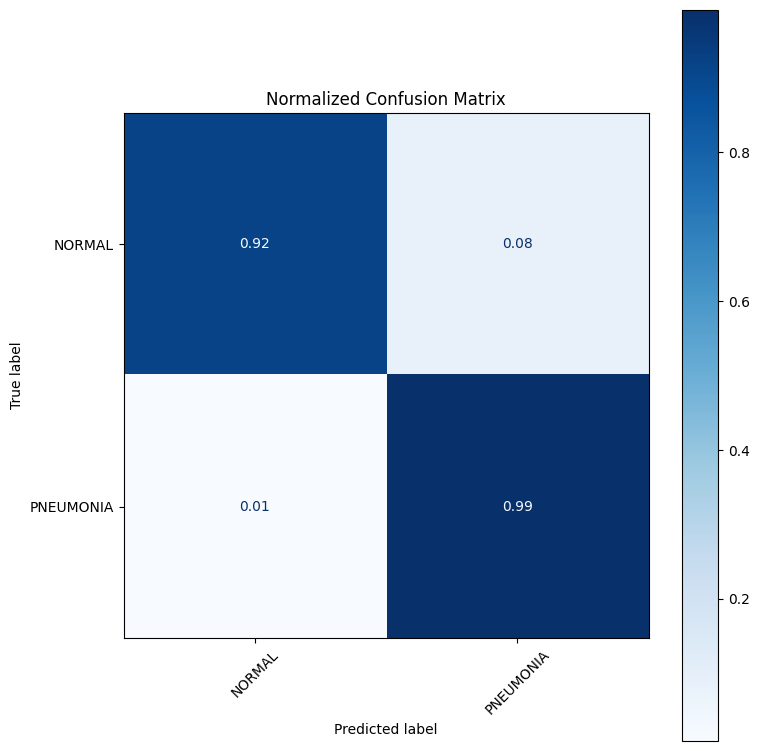

NORMAL              : nan ± nan
PNEUMONIA           : nan ± nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
import random
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import shutil
from sklearn.preprocessing import label_binarize

# =========================================================
# CONFIG
# =========================================================
SEEDS = [42, 52, 62, 72, 82]
EPOCHS = 100

class_metric_history = {
    cls: {
        "precision": [],
        "recall": [],
        "f1-score": []
    }
    for cls in cat
}

metric_history = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "micro_auc": []
}

class_auc_history = {
    cls: [] for cls in le.classes_
}

# =========================================================
# SET SEED
# =========================================================
def set_seed(seed):
    tf.keras.utils.set_random_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

# =========================================================
# CROSS VALIDATION
# =========================================================
# all_fold_results = []
all_true = []
all_pred = []
all_prob = []
for seed in SEEDS:
    print(f"\n========== SEED {seed} ==========")
    save_path = f"/kaggle/working/model_{seed}.keras"
    set_seed(seed)

    time_callback = TimeHistory()
        
    EarlyStopping = tf.keras.callbacks.EarlyStopping
    ReduceLROnPlateau = tf.keras.callbacks.ReduceLROnPlateau
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-5
    )
    
    early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    model_checkpoint = tf.keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

    # Build fresh model
    model = build_model()
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer = optimizer,
        # loss=focal_loss(),
        metrics=['accuracy']
    )
    # Train
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        # class_weight=class_weight,
        epochs=EPOCHS,
        callbacks=[
            model_checkpoint,
            reduce_lr,
            time_callback,
            # early_stop
        ],
        # verbose=1
    )

    # ==========================
    # Predictions
    # ==========================
    model.load_weights('best_model.keras')
    
    y_prob = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = np.array(y_test)

    all_true.extend(y_true)
    all_pred.extend(y_pred)
    all_prob.append(y_prob)
    
    # ==========================
    # Classification Report
    # ==========================
    model.save(save_path)
    print(f"Saved model: {save_path}")
    
    shutil.make_archive(
        f"/kaggle/working/model_{seed}",
        'zip',
        "/kaggle/working",
        f"model_{seed}.keras"
    )
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=cat,
            digits=4
        )
    )
    report = classification_report(
        y_true,
        y_pred,
        target_names=cat,
        output_dict=True,
        zero_division=0
    )

    for cls in cat:
        class_metric_history[cls]["precision"].append(
            report[cls]["precision"]
        )
        class_metric_history[cls]["recall"].append(
            report[cls]["recall"]
        )
        class_metric_history[cls]["f1-score"].append(
            report[cls]["f1-score"]
        )
    # ==========================
    # Standard Metrics
    # ==========================
    
    acc = accuracy_score(y_true, y_pred)
    
    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
    
    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
    
    f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
    
    metric_history["accuracy"].append(acc)
    metric_history["precision"].append(precision)
    metric_history["recall"].append(recall)
    metric_history["f1"].append(f1)
    
    # ==========================
    # ROC AUC
    # ==========================
    
    
    y_true_bin = label_binarize(
        y_true,
        classes=np.arange(num_classes)
    )
    
    n_classes = y_prob.shape[1]

    micro_auc = None

    if n_classes == 2:
        micro_auc = roc_auc_score(
            y_true,
            y_prob[:, 1]
        )
    
        metric_history["micro_auc"].append(micro_auc)
        print(f"AUC: {micro_auc:.4f}")
    
    else:
    
        y_true_bin = label_binarize(
            y_true,
            classes=np.arange(n_classes)
        )
    
        for i in range(len(le.classes_)):
    
            auc_i = roc_auc_score(
                y_true_bin[:, i],
                y_prob[:, i]
            )
    
            cls_name = le.classes_[i]
            class_auc_history[cls_name].append(auc_i)
    
        micro_auc = roc_auc_score(
            y_true_bin,
            y_prob,
            average="micro",
            multi_class="ovr"
        )
    
        metric_history["micro_auc"].append(micro_auc)
        
    
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"Micro AUC: {micro_auc:.4f}")


# =========================================================
# FINAL RESULTS
# =========================================================
print("\n======================================")
print("OVERALL RESULTS")
print("======================================")

for metric_name, values in metric_history.items():

    mean_test = np.mean(values)
    std_test = np.std(values)

    print(
        f"{metric_name:<10}: "
        f"{mean_test:.4f} ± {std_test:.4f}"
    )

print("\nClass-wise ROC-AUC")
all_true = np.array(all_true)
all_pred = np.array(all_pred)
print("\n=== CLASS-WISE METRICS (Mean ± Std) ===")

for cls in cat:

    print(f"\n{cls}")

    for metric in ["precision", "recall", "f1-score"]:

        values = np.array(
            class_metric_history[cls][metric],
            dtype=np.float64
        )

        print(
            f"{metric:<10}: "
            f"{np.mean(values):.4f} ± {np.std(values):.4f}"
        )
print("\n=== POOLED CONFUSION MATRIX ===")
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_true, all_pred)

fig, ax = plt.subplots(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=True
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
print("\n=== POOLED CLASSIFICATION REPORT ===")

print(
    classification_report(
        all_true,
        all_pred,
        target_names=cat,
        digits=4
    )
)

cm_norm = confusion_matrix(
    all_true,
    all_pred,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=le.classes_
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format=".2f",
    colorbar=True
)

plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

for cls_name, values in class_auc_history.items():
    mean_auc = np.mean(values)
    std_auc = np.std(values)

    print(
        f"{cls_name:<20}: "
        f"{mean_auc:.4f} ± {std_auc:.4f}"
    )

In [18]:
model = build_model()
model.summary()
model.load_weights("best_model.keras")
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ input_layer_5[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 224, 224,  │        896 │ rescaling_5[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 112, 112,  │          0 │ activation_20[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 112, 112,  │          0 │ max_pooling2d_20… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 112, 112,  │     18,496 │ dropout_25[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 56, 56,    │          0 │ activation_21[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 56, 56,    │          0 │ max_pooling2d_21… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 56, 56,    │     73,856 │ dropout_26[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_42[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_22    │ (None, 28, 28,    │          0 │ activation_22[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 28, 28,    │          0 │ max_pooling2d_22

 Total params: 587,842 (2.24 MB)

 Trainable params: 585,858 (2.23 MB)

 Non-trainable params: 1,984 (7.75 KB)

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 254ms/step
              precision    recall  f1-score   support

           0     0.9662    0.9051    0.9346       158
           1     0.9658    0.9883    0.9769       428

    accuracy                         0.9659       586
   macro avg     0.9660    0.9467    0.9558       586
weighted avg     0.9659    0.9659    0.9655       586



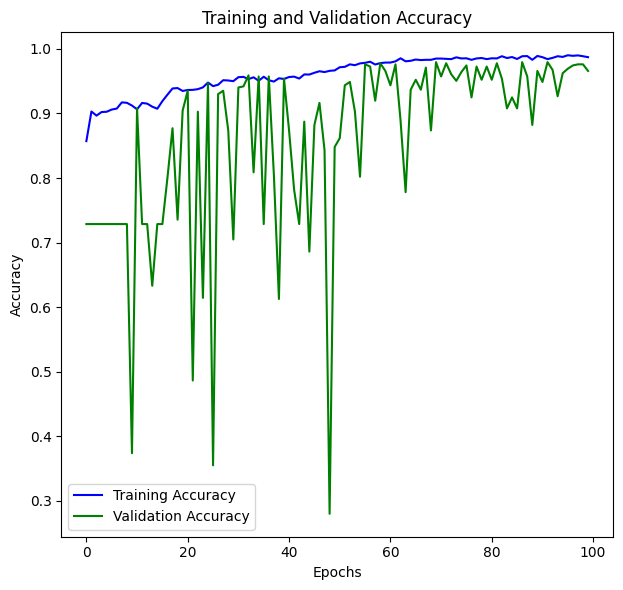

In [ ]:
y_test[:5]
pred = np.argmax(model.predict(test_ds), axis = -1)

pred[:5]

print(classification_report(y_test, pred, digits = 4))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='green')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.tight_layout()
plt.show()

In [ ]:
def get_flops(model):
    if not model.built:
        raise ValueError("Model must be built before computing FLOPs.")

    input_specs = []
    for inp in model.inputs:
        shape = [1 if dim is None else dim for dim in inp.shape]
        input_specs.append(tf.TensorSpec(shape=shape, dtype=inp.dtype))

    # Create concrete function
    @tf.function
    def forward(*inputs):
        return model(inputs if len(inputs) > 1 else inputs[0], training=False)
    
    # warm-up pass
    dummy_input = tf.random.normal([1, IMG_SIZE, IMG_SIZE, 3])
    model(dummy_input, training=False)
    
    concrete_func = forward.get_concrete_function(*input_specs)

    # Freeze the graph
    frozen_func = convert_variables_to_constants_v2(concrete_func)
    graph_def = frozen_func.graph.as_graph_def()

    # Profile FLOPs
    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name='')
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops = tf.compat.v1.profiler.profile(
            graph, run_meta=run_meta, options=opts
        )

    return flops.total_float_ops if flops is not None else 0

flops = get_flops(model)
print("FLOPs:", flops)
print("GFLOPs:", flops / 1e9)

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


I0000 00:00:1781009741.924703      23 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1781009741.924966      23 single_machine.cc:374] Starting new session
I0000 00:00:1781009741.925993      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
scope: The nodes in the model graph are organized by their names, which is hierarchical like filesystem.
flops: Number of float operations. Note: Please read the implementation for the math behind it.

Profi

In [27]:
# Inference speed
import time

start = time.time()
model.predict(test_ds)
end = time.time()

print("Inference time:", end - start)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step
Inference time: 1.7388768196105957


# Save and load model to simulate HITL feedback

In [28]:
# model.save("/kaggle/working/model.keras")
# os.listdir("/kaggle/working")

# import shutil

# shutil.make_archive("/kaggle/working/model", 'zip', "/kaggle/working", "model.keras")

# HITL Simulation

In [ ]:
logs = []
# model = load_model("model.keras", compile=False)
for i in range(3):
    print(f"\n===== ITERATION {i+1} =====")

    # Load latest model
    if(i != 0):
        model = load_model("hitl_model.keras", compile=False)

    # ------------------------
    # Step 1: Inference on val
    # ------------------------
    val_probs = model.predict(val_ds)
    val_preds = np.argmax(val_probs, axis=1)
    val_conf = np.max(val_probs, axis=1)

    error_idx = val_preds != y_val
    error_rate = np.mean(error_idx)

    print("Val error rate:", error_rate)

    # ------------------------
    # Step 2: Select hard samples
    # ------------------------
    hard_idx = (val_conf < 0.7) | error_idx


    X_hard = X_val.iloc[hard_idx]['image_path'].values
    y_hard = y_val[hard_idx]

    hard_ds_eval = make_dataset(
        X_hard,
        y_hard.astype(np.int32),
        training=False
    )
    
    hard_probs_before = model.predict(hard_ds_eval, verbose=0)
    hard_preds_before = np.argmax(hard_probs_before, axis=1)
    
    hard_acc_before = accuracy_score(
        y_hard,
        hard_preds_before
    )
    
    hard_f1_before = f1_score(
        y_hard,
        hard_preds_before,
        average="macro"
    )
    
    print(f"Hard Acc Before: {hard_acc_before*100:.2f}%")
    print(f"Hard F1 Before : {hard_f1_before*100:.2f}%")

    print("Samples sent to human:", len(X_hard))

    # ------------------------
    # Step 3: Build dataset
    # ------------------------
    def preprocess(x, y):
        x = tf.io.read_file(x)
        x = tf.image.decode_jpeg(x, channels=3)
        x = tf.image.resize(x, (IMG_SIZE, IMG_SIZE))
        x = tf.cast(x, tf.float32)
        y = tf.cast(y, tf.int32)
        return x, y

    hard_ds = tf.data.Dataset.from_tensor_slices((X_hard, y_hard))
    hard_ds = hard_ds.map(preprocess)
    hard_ds = hard_ds.batch(BATCH_SIZE)

    train_combined_ds = train_ds.concatenate(hard_ds)
    train_combined_ds = train_combined_ds.shuffle(buffer_size=len(X_train) + len(X_hard)).prefetch(tf.data.AUTOTUNE)

    # ------------------------
    # Step 4: Freeze + compile
    # ------------------------
    # for layer in model.layers:
    #     layer.trainable = False
    
    # for layer in model.layers[20:]:
    #     layer.trainable = True

    for layer in model.layers:
        layer.trainable = False
    
    for layer in model.layers[17:]:
        layer.trainable = True
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # ------------------------
    # Step 5: Evaluate BEFORE
    # ------------------------
    test_probs_before = model.predict(test_ds)
    test_preds_before = np.argmax(test_probs_before, axis=1)
    
    acc_before = accuracy_score(y_test, test_preds_before)
    f1_before = f1_score(y_test, test_preds_before, average="macro")
    
    cm_before = confusion_matrix(
        y_test,
        test_preds_before,
        normalize="true"
    )
    
    report_before = classification_report(
        y_test,
        test_preds_before,
        target_names=cat,
        output_dict=True,
        zero_division=0
    )
    
    print(f"Before Acc: {acc_before*100:.2f}%")
    print(f"Before F1 : {f1_before*100:.2f}%")
    
    print("\nClassification Report BEFORE")
    print(pd.DataFrame(report_before).transpose().round(4))
    
    print("\nNormalized Confusion Matrix BEFORE (%)")
    print(np.round(cm_before * 100, 2))

    # ------------------------
    # Step 6: Train
    # ------------------------
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        f"best_hitl_iteration_{i+1}.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )
    model.fit(
        train_combined_ds,
        epochs=10,
        callbacks=[checkpoint],
        verbose=1)

    # ------------------------
    # Step 7: Evaluate AFTER
    # ------------------------
    model = tf.keras.models.load_model(f"best_hitl_iteration_{i+1}.keras")
    
    test_probs_after = model.predict(test_ds)
    test_preds_after = np.argmax(test_probs_after, axis=1)
    
    acc_after = accuracy_score(y_test, test_preds_after)
    f1_after = f1_score(y_test, test_preds_after, average="macro")
    
    cm_after = confusion_matrix(
        y_test,
        test_preds_after,
        normalize="true"
    )
    
    report_after = classification_report(
        y_test,
        test_preds_after,
        target_names=cat,
        output_dict=True,
        zero_division=0
    )
    
    print(f"After Acc: {acc_after*100:.2f}%")
    print(f"After F1 : {f1_after*100:.2f}%")
    
    print("\nClassification Report AFTER")
    print(pd.DataFrame(report_after).transpose().round(4))
    
    print("\nNormalized Confusion Matrix AFTER (%)")
    print(np.round(cm_after * 100, 2))

    hard_probs_after = model.predict(hard_ds_eval, verbose=0)
    hard_preds_after = np.argmax(hard_probs_after, axis=1)
    
    hard_acc_after = accuracy_score(
        y_hard,
        hard_preds_after
    )
    
    hard_f1_after = f1_score(
        y_hard,
        hard_preds_after,
        average="macro"
    )

    print(classification_report(
        y_hard,
        hard_preds_before,
        target_names=cat
    ))
    
    print(classification_report(
        y_hard,
        hard_preds_after,
        target_names=cat
    ))
    
    print(confusion_matrix(y_hard, hard_preds_before))
    print(confusion_matrix(y_hard, hard_preds_after))
    
    print(f"Hard Acc After: {hard_acc_after*100:.2f}%")
    print(f"Hard F1 After : {hard_f1_after*100:.2f}%")
    
    # ------------------------
    # Step 8: Prediction shift
    # ------------------------
    shift = np.mean(np.abs(test_probs_before - test_probs_after))
    print("Prediction shift:", shift)

    # ------------------------
    # Step 9: Save model
    # ------------------------
    model.save("hitl_model.keras")

    # ------------------------
    # Step 10: Log results
    # ------------------------
    logs.append({
        "iteration": i + 1,
        "val_error_rate": round(error_rate * 100, 2),
        "samples_used": len(X_hard),
    
        "acc_before": round(acc_before * 100, 2),
        "acc_after": round(acc_after * 100, 2),
    
        "f1_before": round(f1_before * 100, 2),
        "f1_after": round(f1_after * 100, 2),
    
        "acc_gain": round((acc_after - acc_before) * 100, 2),
        "f1_gain": round((f1_after - f1_before) * 100, 2),
    
        "shift": round(shift * 100, 2),
    
        "cm_before": np.round(cm_before * 100, 2).tolist(),
        "cm_after": np.round(cm_after * 100, 2).tolist(),
    
        "report_before": {
            k: {m: round(v * 100, 2) if isinstance(v, float) else v
                for m, v in vals.items()}
            if isinstance(vals, dict) else vals
            for k, vals in report_before.items()
        },
    
        "report_after": {
            k: {m: round(v * 100, 2) if isinstance(v, float) else v
                for m, v in vals.items()}
            if isinstance(vals, dict) else vals
            for k, vals in report_after.items()
        }
    })
    forgotten = np.sum(
        (test_preds_before == y_test) &
        (test_preds_after != y_test)
    )
    
    corrected = np.sum(
        (test_preds_before != y_test) &
        (test_preds_after == y_test)
    )
    
    print(f"Corrected samples : {corrected}")
    print(f"Forgotten samples : {forgotten}")

    corrected_hard = np.sum(
        (hard_preds_before != y_hard) &
        (hard_preds_after == y_hard)
    )
    
    forgotten_hard = np.sum(
        (hard_preds_before == y_hard) &
        (hard_preds_after != y_hard)
    )
    
    print("Corrected hard samples:", corrected_hard)
    print("Forgotten hard samples:", forgotten_hard)


===== ITERATION 1 =====
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step
Val error rate: 0.01877133105802048
Hard Acc Before: 52.17%
Hard F1 Before : 52.17%
Samples sent to human: 23
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 288ms/step
Before Acc: 97.44%
Before F1 : 96.70%

Classification Report BEFORE
              precision  recall  f1-score   support
Normal           0.9735  0.9304    0.9515  158.0000
Pneumonia        0.9747  0.9907    0.9826  428.0000
accuracy         0.9744  0.9744    0.9744    0.9744
macro avg        0.9741  0.9605    0.9670  586.0000
weighted avg     0.9744  0.9744    0.9742  586.0000

Normalized Confusion Matrix BEFORE (%)
[[93.04  6.96]
 [ 0.93 99.07]]
Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 57s 264ms/step - accuracy: 0.9790 - loss: 0.0868
Epoch 2/10


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9779 - loss: 0.0924
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9794 - loss: 0.0885
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9826 - loss: 0.0827
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9800 - loss: 0.0865
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9796 - loss: 0.0892
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9805 - loss: 0.0869
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9802 - loss: 0.0849
Epoch 9/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9851 - loss: 0.0809
Epoch 10/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9805 - loss: 0.0839
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 288ms/step
After Acc: 96.08%
After F1 : 94.77%

Classification Report AFTER
              precision  recall  f1-score   support
Normal           1.0000  0.8544    0.9215  158.0000
Pneumonia        0.9490  1.0000    

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9761 - loss: 0.1027
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9752 - loss: 0.1019
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9733 - loss: 0.1000
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9765 - loss: 0.0996
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9769 - loss: 0.0985
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9780 - loss: 0.0972
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9767 - loss: 0.0970
Epoch 9/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9771 - loss: 0.0958
Epoch 10/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9748 - loss: 0.0987
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 287ms/step
After Acc: 94.54%
After F1 : 92.56%

Classification Report AFTER
              precision  recall  f1-score   support
Normal           1.0000  0.7975    0.8873  158.0000
Pneumonia        0.9304  1.0000    

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9742 - loss: 0.1051
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9755 - loss: 0.1056
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.9746 - loss: 0.1076
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9727 - loss: 0.1072
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9763 - loss: 0.1008
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9755 - loss: 0.1011
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9730 - loss: 0.1033
Epoch 9/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9740 - loss: 0.1005
Epoch 10/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9744 - loss: 0.1014
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 286ms/step
After Acc: 97.61%
After F1 : 96.93%

Classification Report AFTER
              precision  recall  f1-score   support
Normal           0.9737  0.9367    0.9548  158.0000
Pneumonia        0.9770  0.9907    

In [ ]:
model.save("/kaggle/working/new_model.keras")